In [ ]:
import pandas as pd
import numpy as np

# Set random seed so results are reproducible
np.random.seed(42)

# Create 100 sample house records
data = {
    'Area': np.random.randint(800, 3500, size=100),
    'Bedrooms': np.random.randint(1, 5, size=100),
    'Bathrooms': np.random.randint(1, 4, size=100)
}

# Formula with noise: Price = (Area * 150) + (Bedrooms * 10000) + (Bathrooms * 15000) + noise
data['Price'] = (
    data['Area'] * 150 +
    data['Bedrooms'] * 10000 +
    data['Bathrooms'] * 15000 +
    np.random.normal(0, 15000, size=100)
)

# Convert dictionary to Pandas DataFrame
df = pd.DataFrame(data)

# Introduce a few missing values (NaNs) to simulate real-world raw data
df.loc[5, 'Area'] = np.nan
df.loc[12, 'Bathrooms'] = np.nan

# Inspect the first 10 rows
print("--- FIRST 10 ROWS OF RAW DATA ---")
print(df.head(10))

--- FIRST 10 ROWS OF RAW DATA ---
     Area  Bedrooms  Bathrooms          Price
0  1660.0         1        1.0  263799.629176
1  2094.0         2        3.0  382583.805457
2  1930.0         3        3.0  368896.087099
3  1895.0         2        2.0  323534.728730
4  2438.0         1        3.0  448686.617667
5     NaN         4        1.0  507457.493814
6  1266.0         3        2.0  232030.447542
7  2038.0         1        1.0  340548.304130
8  1130.0         4        1.0  209879.774947
9  2282.0         4        3.0  439106.269056


In [ ]:
# Check missing values before fixing
print("Missing values before fix:")
print(df.isnull().sum())

# Fill missing values using the median of each column
df['Area'] = df['Area'].fillna(df['Area'].median())
df['Bathrooms'] = df['Bathrooms'].fillna(df['Bathrooms'].median())

# Check missing values again to confirm they are fixed
print("\nMissing values after fix:")
print(df.isnull().sum())

Missing values before fix:
Area         1
Bedrooms     0
Bathrooms    1
Price        0
dtype: int64

Missing values after fix:
Area         0
Bedrooms     0
Bathrooms    0
Price        0
dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

# 1. Define Features (X) and Target (y)
X = df[['Area', 'Bedrooms', 'Bathrooms']]
y = df['Price']

# 2. Split into 80% Training data and 20% Testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total rows: {len(df)}")
print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

Total rows: 100
Training rows: 80
Testing rows: 20


In [ ]:
from sklearn.linear_model import LinearRegression

# 1. Create the model instance
model = LinearRegression()

# 2. Train (fit) the model on our training data
model.fit(X_train, y_train)

print("Model training complete! 🎉")

Model training complete! 🎉


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# 1. Predict prices for test data
y_pred = model.predict(X_test)

# 2. Calculate accuracy metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"R-squared Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:,.2f}")

# 3. Test with a custom house input
sample_house = pd.DataFrame({'Area': [2000], 'Bedrooms': [3], 'Bathrooms': [2]})
predicted_price = model.predict(sample_house)[0]

print(f"\n--- CUSTOM PREDICTION ---")
print(f"House Details: 2000 sq ft, 3 Bedrooms, 2 Bathrooms")
print(f"Estimated Price: ${predicted_price:,.2f}")

R-squared Score: 0.9890
Mean Squared Error: 171,524,218.84

--- CUSTOM PREDICTION ---
House Details: 2000 sq ft, 3 Bedrooms, 2 Bathrooms
Estimated Price: $362,510.48


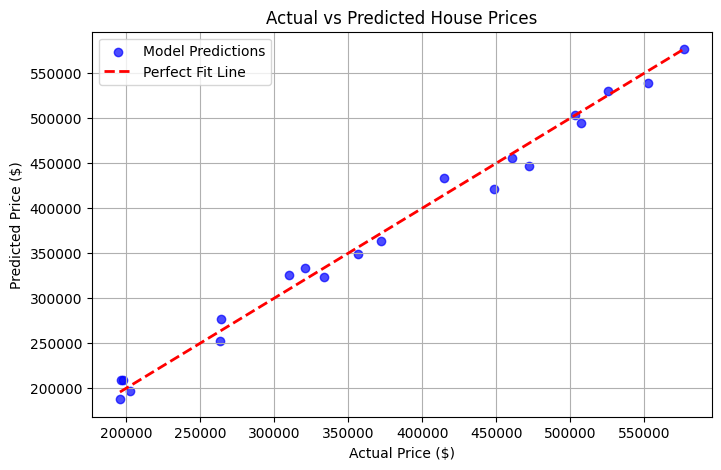

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Plot actual vs predicted prices
plt.scatter(y_test, y_pred, color='blue', alpha=0.7, label='Model Predictions')

# Draw perfect prediction reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit Line')

plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.grid(True)

plt.show()